# Extended Data Fig. 26b - Measurement variability (CV) of practical 2D sampling (AppNL-G-F)

Using optically derived coronal sections from the 3D whole-brain App-NL-G-F dataset (ages 1,3,5,7,9 m; n=4/age, n=20), two practical 2D sampling protocols are evaluated: Protocol 1 (random coronal sections, whole-slide coverage) and Protocol 2 (uniform-interval coronal sections, stereology-style). The Normalized Average CV2D (normalized so the 3D ground-truth CV3D = 1.0) is plotted against sampling density for Abeta, neurons, microglia and non-neuronal cells.

> Figures preserved from the original run; Japanese stripped from comments; verbose logs removed.

## Input files

| File | Content |
|---|---|
| optically-derived per-section regional measurements (App time-course) | 2D sampling inputs |
| `normalized_cv_results_APP_9m.csv` | precomputed normalized CV table (Protocol 2 plot) |
| 3D whole-brain reference regional densities | CV3D normalization (=1.0) |

## Protocol 1 - Normalized CV2D vs number of sampled sections

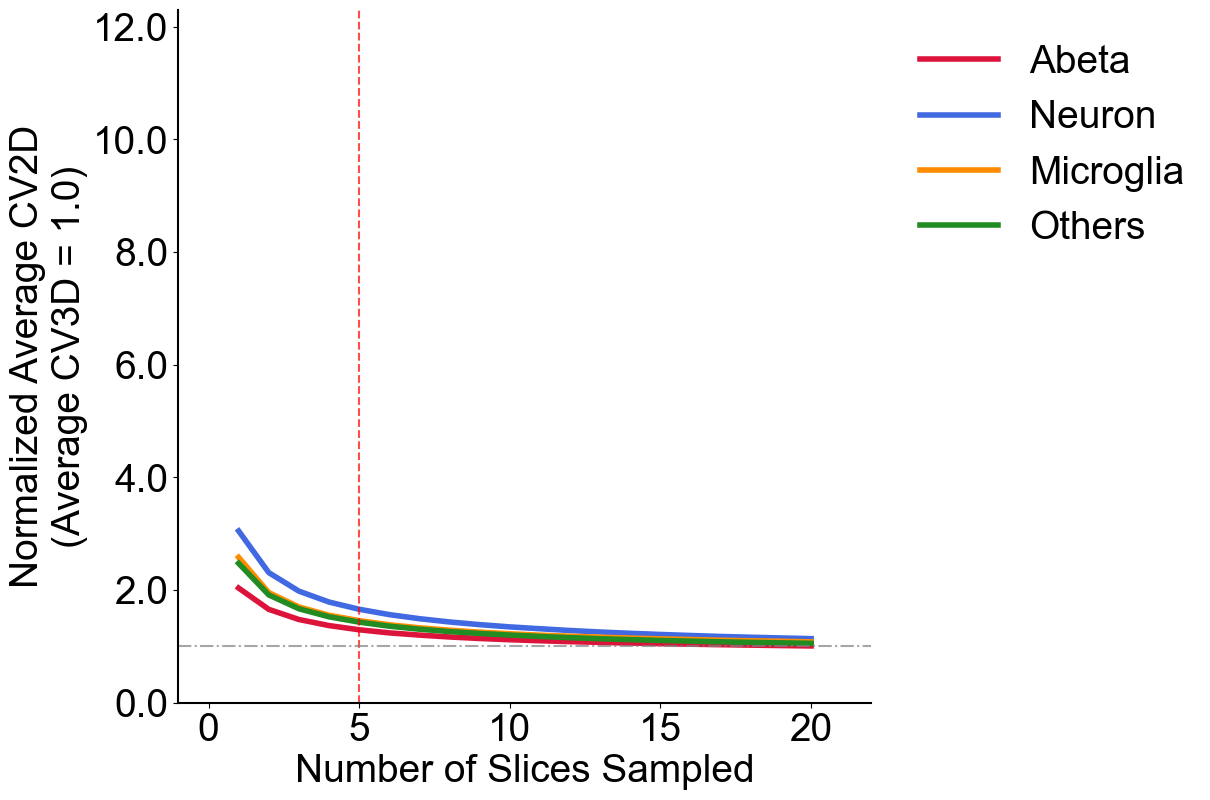

In [1]:
# 250901
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "APP_9m" #  

cell_types_to_plot = {
    "Abeta":   {"file_tag": "abeta",   "color": "crimson",   "label": "Abeta"},
    "NeuN":   {"file_tag": "neun",   "color": "royalblue",   "label": "Neuron"},
    "Iba1":   {"file_tag": "iba1",   "color": "darkorange",  "label": "Microglia"},
    "Others": {"file_tag": "others", "color": "forestgreen", "label": "Others"}
}

#
output_base_path = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
output_pdf_path = os.path.join(output_base_path, f"Rescaled_Raw_cv_2D_vs_slice_count_{GROUP_TO_ANALYZE}_filtered.pdf")
#
output_csv_path = os.path.join(output_base_path, f"cv_analysis_vs_slice_count_{GROUP_TO_ANALYZE}_summary.csv")


#
if __name__ == "__main__":
    
    #
    all_results_df = pd.DataFrame()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.use14corefonts'] = True
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    #
    for cell_type, params in cell_types_to_plot.items():
        filename = os.path.join(output_base_path, f"cv_analysis_vs_slice_count_{GROUP_TO_ANALYZE}_{params['file_tag']}.csv")
        try:
            df = pd.read_csv(filename, index_col='region_id')
            
            #
            df_raw_cv = df.filter(like='_raw_cv')
            s_3d_cv = df['3d_cv']
            mean_3d_cv = s_3d_cv.mean()
            df_scaled_cv = df_raw_cv / mean_3d_cv
            
            df_scaled_cv.columns = df_scaled_cv.columns.str.replace('slices_', '').str.replace('_raw_cv', '').astype(int)
            
            mean_scaled_cv = df_scaled_cv.mean(axis=0)
            std_scaled_cv = df_scaled_cv.std(axis=0)

            #
            mean_to_plot = mean_scaled_cv.loc[1:20]
            std_to_plot = std_scaled_cv.loc[1:20]
            
            #
            df_temp_results = pd.DataFrame({
                'Number of Slices': mean_to_plot.index,
                'Mean Scaled CV': mean_to_plot.values,
                'Std Scaled CV': std_to_plot.values
            })
            df_temp_results['Cell Type'] = params['label']
            
            #
            all_results_df = pd.concat([all_results_df, df_temp_results], ignore_index=True)


            #
            ax.plot(mean_to_plot.index, mean_to_plot.values,
                    linewidth=4,
                    color=params['color'],
                    label=params['label'])
            
            ax.fill_between(
                std_to_plot.index,
                (mean_to_plot - std_to_plot),
                (mean_to_plot + std_to_plot),
                color=params['color'],
                alpha=0.0
            )

        except (FileNotFoundError, KeyError) as e:
            print(f"WARNING: Could not process {filename}. Reason: {e}")
            continue

    #
    ax.set_xlabel('Number of Slices Sampled', fontsize=28)
    ax.set_ylabel('Normalized Average CV2D\n(Average CV3D = 1.0)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.axvline(x=5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=1.0, color='gray', linestyle='dashdot', linewidth=1.5, alpha=0.7)
    ax.set_ylim(bottom=0, top=12.3)
    ax.set_xlim(left=-1, right=22)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    formatter = mticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(formatter)
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    ax.set_aspect(aspect=x_range/y_range, adjustable='box')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)

    #
    #
    plt.savefig(output_pdf_path, transparent=True, dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f"\nPlot saved to: {output_pdf_path}")
    
    #
    all_results_df.to_csv(output_csv_path, index=False)
    print(f"Results summary saved to: {output_csv_path}")

    plt.show()

## Protocol 2 - Normalized CV2D vs section interval (um)

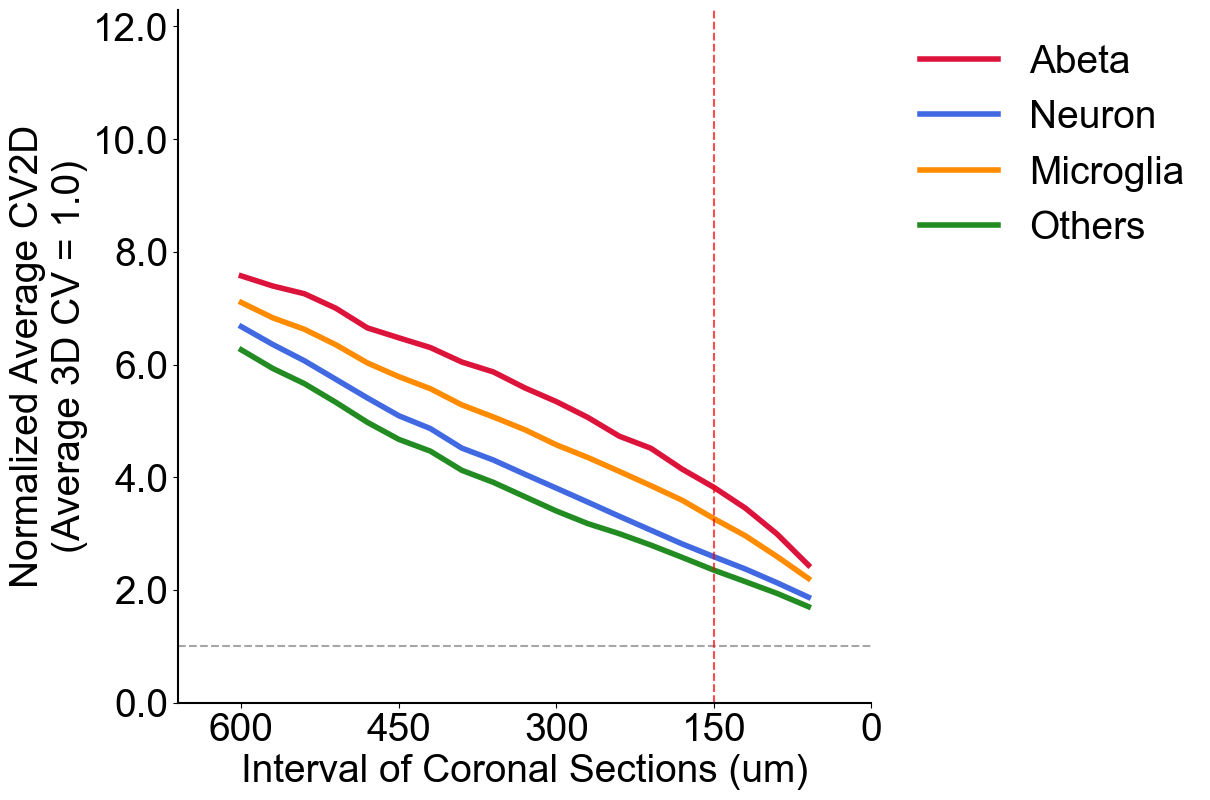

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker

#
#
INPUT_CSV_FILENAMES = [
    "normalized_cv_results_APP_9m.csv",
    #"normalized_cv_results_APP_9m_abeta.csv"
]

#
CELL_TYPE_MAPPING = {
    "abeta": {"column": "Abeta_density (/mm3)", "color": "crimson", "label": "Abeta"},
    "neun": {"column": "NeuN+ density (/mm3)", "color": "royalblue", "label": "Neuron"},
    "iba1": {"column": "Iba1+ density (/mm3)", "color": "darkorange", "label": "Microglia"},
    "others": {"column": "Others density (/mm3)", "color": "forestgreen", "label": "Others"}
}

#
LEGEND_ORDER = ["Abeta", "Neuron", "Microglia", "Others"]

#
OUTPUT_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"

#
if __name__ == "__main__":
    #
    df_combined_results = pd.DataFrame()

    #
    for filename in INPUT_CSV_FILENAMES:
        file_path = os.path.join(OUTPUT_PATH, filename)
        try:
            df = pd.read_csv(file_path)
            df['Group'] = filename.replace('normalized_cv_results_', '').replace('.csv', '')
            df_combined_results = pd.concat([df_combined_results, df], ignore_index=True)
            print(f"Successfully loaded data from: {file_path}")
        except FileNotFoundError:
            print(f"ERROR: The file '{file_path}' was not found. Skipping.")
            continue
    
    if df_combined_results.empty:
        print("No data loaded. Exiting.")
        exit()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    #
    #
    for cell_type_label in LEGEND_ORDER:
        df_cell_type = df_combined_results[df_combined_results['Cell Type'] == cell_type_label]
        
        if df_cell_type.empty:
            print(f"Warning: No data found for cell type '{cell_type_label}'. Skipping.")
            continue
        
        #
        color = 'black'
        for key, val in CELL_TYPE_MAPPING.items():
            if val['label'] == cell_type_label:
                color = val['color']
                break

        #
        plot_mask = (df_cell_type['Span (um)'] >= 60) & (df_cell_type['Span (um)'] <= 600)
        span_values = df_cell_type.loc[plot_mask, 'Span (um)'].values
        mean_norm_cv_values = df_cell_type.loc[plot_mask, 'Mean Normalized CV'].values
        std_norm_cv_values = df_cell_type.loc[plot_mask, 'Std Normalized CV'].values
        
        #
        ax.plot(span_values, mean_norm_cv_values,
                linewidth=4,
                color=color,
                label=cell_type_label
                )
        
        ax.fill_between(
            span_values,
            mean_norm_cv_values - std_norm_cv_values,
            mean_norm_cv_values + std_norm_cv_values,
            color=color,
            alpha=0.0
        )

    #
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Interval of Coronal Sections (um)', fontsize=28)
    ax.set_ylabel('Normalized Average CV2D\n(Average 3D CV = 1.0)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)

    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(x=150, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

    #
    ax.set_ylim(bottom=0, top=12.3)
    ax.set_xlim(left=660, right=30)
    ax.set_xticks([600, 450, 300, 150, 0])
    
    x_range = abs(ax.get_xlim()[1] - ax.get_xlim()[0])
    y_range = abs(ax.get_ylim()[1] - ax.get_ylim()[0])

    if y_range > 0 and x_range > 0:
        ax.set_aspect(aspect=x_range / y_range, adjustable='box')
    else:
        print("Warning: The axis range is not positive. Aspect ratio was not set.")

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=28, frameon=False)
    formatter = mticker.FormatStrFormatter('%.1f')
    ax.yaxis.set_major_formatter(formatter)
    
    #
    output_plot_filename = os.path.join(
        OUTPUT_PATH,
        f"combined_cv_analysis_stereology_vs_span_APP_9m.pdf"
    )

    plt.savefig(output_plot_filename, transparent=True, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nPlot saved to: {output_plot_filename}")